In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = '/content/drive/MyDrive/DEEPLRL_Data'

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [4]:
datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

In [5]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode='categorical',
    subset = 'training'
)

Found 600 images belonging to 5 classes.


In [6]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size = (128,128),
    batch_size = 32,
    class_mode='categorical',
    subset = 'validation'
)

Found 150 images belonging to 5 classes.


In [7]:
model = models.Sequential()

In [8]:
model.add(layers.Conv2D(32,(3,3),
                        activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(layers.Conv2D(64,(3,3),
                        activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

In [10]:
model.add(layers.Flatten())

In [11]:
model.add(layers.Dense(train_data.num_classes, activation='softmax'))

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    epochs = 10,
    validation_data = validation_data
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 268s 14s/step - accuracy: 0.4350 - loss: 1.5326 - val_accuracy: 0.4067 - val_loss: 1.4264
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 66s 3s/step - accuracy: 0.8033 - loss: 0.6242 - val_accuracy: 0.5733 - val_loss: 1.6049
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.8617 - loss: 0.3808 - val_accuracy: 0.5067 - val_loss: 1.7834
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 91s 4s/step - accuracy: 0.9133 - loss: 0.2668 - val_accuracy: 0.5733 - val_loss: 2.2697
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 65s 3s/step - accuracy: 0.9633 - loss: 0.1348 - val_accuracy: 0.5733 - val_loss: 2.3841
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.9683 - loss: 0.1100 - val_accuracy: 0.5933 - val_loss: 2.2947
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 69s 4s/step - accuracy: 0.9900 - loss: 0.0524 - val_accuracy: 0.5867 - val_loss: 2.5144
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 67s 4s/step - accuracy: 0.9983 - loss: 0.0284 - val_accuracy: 0.5933 - val_los

In [14]:
loss, accuracy = model.evaluate(validation_data)
print('Validation Accuracy:', accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5867 - loss: 3.2025
Validation Accuracy: 0.5866666436195374


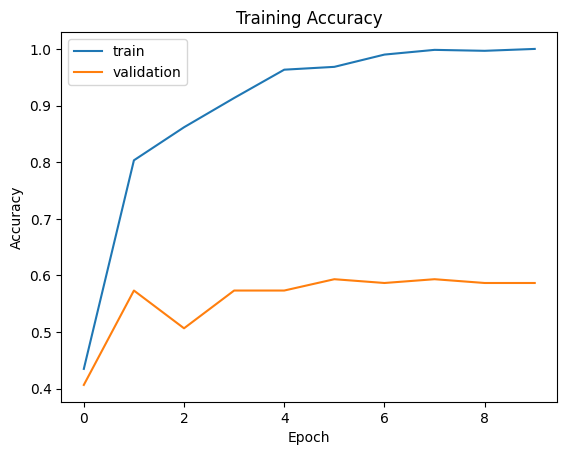

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])

plt.show()

In [16]:
model.save("cnn_classifier.h5")

In [17]:
from google.colab import files
files.download("cnn_classifier.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Streamlit next

In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


In [ ]:


# Upload image from local computer
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]

# Load and resize image
img = image.load_img(filename, target_size=(128,128))

# Convert image to array
img_array = image.img_to_array(img)

# Normalize pixel values
img_array = img_array / 255.0

# Expand dimensions to match model input
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get predicted class index
predicted_class = np.argmax(prediction)

# Get class label names
class_labels = list(train_data.class_indices.keys())



In [ ]:
# Display image
plt.imshow(img)
plt.axis('off')
plt.title("Predicted Class: " + class_labels[predicted_class])
plt.show()